# Risk ratio de dry spells largos en 4 regiones de Chile

Pregunta: ¿cambió la probabilidad de **dry spells** largos entre **1979–2000** y **2001–2021**?

Referencia metodológica: Martinez-Villalobos & Neelin (2018), [10.1029/2018GL078465](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2018GL078465).

## Definiciones
- **Día seco:** precipitación diaria `pr < 1 mm/día` (CR2MET v2.5).
- **Dry spell:** racha consecutiva de días secos.
- **Evento:** dry spell con duración ≥ umbral (p. ej. 20 días).
- **Probabilidad del evento:** fracción de rachas (spells) con duración ≥ umbral; cada racha se asigna al **año de inicio**.
- **Risk ratio (RR):** P₂/P₁, donde P₁ y P₂ son las probabilidades en 1979–2000 y 2001–2021.
- **Pool regional:** se agrupan todas las rachas de los píxeles CR2MET dentro de cada región administrativa (Natural Earth).

## Regiones analizadas
Coquimbo, O'Higgins, La Araucanía y Los Lagos (mismas definiciones que en `preg2(fecha17abril).ipynb`).


In [1]:
import warnings
import unicodedata
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.prepared import prep
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from IPython.display import display

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linestyle'] = ':'

# =====================================================================
# CONFIGURACION GENERAL
# =====================================================================
START_DATE = '1979-01-01'
END_DATE = '2021-12-31'
DRY_THRESHOLD = 1.0
EVENT_THRESHOLD = 20
BOOTSTRAP_ITER = 300
RANDOM_SEED = 42
PERIOD_1 = (1979, 2000)
PERIOD_2 = (2001, 2021)
THRESHOLD_SWEEP = [5, 10, 15, 20, 25, 30, 35, 40]

REGION_SPECS = {
    'Coquimbo': {'query': 'Coquimbo', 'color': 'firebrick'},
    "O'Higgins": {'query': 'higgins', 'color': 'darkorange'},
    'La Araucanía': {'query': 'araucan', 'color': 'forestgreen'},
    'Los Lagos': {'query': 'los lagos', 'color': 'steelblue'},
}

# =====================================================================
# FUNCIONES AUXILIARES
# =====================================================================
def normalize_text(text):
    text = unicodedata.normalize('NFKD', str(text).lower())
    return ''.join(ch for ch in text if not unicodedata.combining(ch))


def get_region_record(query, chile_records):
    query_norm = normalize_text(query)
    for record in chile_records:
        name_norm = normalize_text(record.attributes.get('name', ''))
        if query_norm in name_norm:
            return record
    raise ValueError(f'No se encontro region chilena para: {query}')


def build_region_mask(lat2d, lon2d, polygon):
    prepg = prep(polygon)
    return np.fromiter(
        (
            prepg.contains(Point(float(lon2d[j, i]), float(lat2d[j, i])))
            or polygon.touches(Point(float(lon2d[j, i]), float(lat2d[j, i])))
            for j in range(lat2d.shape[0])
            for i in range(lat2d.shape[1])
        ),
        dtype=bool,
        count=lat2d.size,
    ).reshape(lat2d.shape)


def extract_dry_spells(pr_values, times, threshold):
    records = []
    nlat, nlon = pr_values.shape[1], pr_values.shape[2]
    times = pd.to_datetime(times)

    for j in range(nlat):
        for i in range(nlon):
            vals = pr_values[:, j, i]
            if np.all(np.isnan(vals)):
                continue

            is_dry = np.isfinite(vals) & (vals < threshold)
            x = np.concatenate(([0], is_dry.astype(np.int8), [0]))
            dx = np.diff(x)
            starts = np.where(dx == 1)[0]
            ends = np.where(dx == -1)[0]

            for s, e in zip(starts, ends):
                duration = int(e - s)
                if duration > 0:
                    records.append({
                        'start_year': int(times[s].year),
                        'duration': duration,
                    })

    return pd.DataFrame(records)


def event_probability(spell_df, start_year, end_year, min_duration):
    subset = spell_df[
        (spell_df['start_year'] >= start_year) & (spell_df['start_year'] <= end_year)
    ].copy()
    total_spells = int(len(subset))
    event_spells = int((subset['duration'] >= min_duration).sum())
    probability = np.nan if total_spells == 0 else event_spells / total_spells
    return subset, probability, event_spells, total_spells


def risk_ratio(prob_period_2, prob_period_1):
    if prob_period_1 == 0 or not np.isfinite(prob_period_1):
        return np.nan
    return prob_period_2 / prob_period_1


def bootstrap_rr_by_year(spell_df, years_1, years_2, min_duration, n_iter=BOOTSTRAP_ITER, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    grouped = {
        year: spell_df.loc[spell_df['start_year'] == year, 'duration'].to_numpy()
        for year in sorted(spell_df['start_year'].unique())
    }
    years_1 = np.array(list(years_1))
    years_2 = np.array(list(years_2))
    rr_values = []

    for _ in range(n_iter):
        draw_1 = rng.choice(years_1, size=len(years_1), replace=True)
        draw_2 = rng.choice(years_2, size=len(years_2), replace=True)

        sample_1 = np.concatenate([grouped[year] for year in draw_1 if grouped[year].size > 0])
        sample_2 = np.concatenate([grouped[year] for year in draw_2 if grouped[year].size > 0])

        if sample_1.size == 0 or sample_2.size == 0:
            continue

        p1 = np.mean(sample_1 >= min_duration)
        p2 = np.mean(sample_2 >= min_duration)
        if p1 > 0:
            rr_values.append(p2 / p1)

    return np.array(rr_values)


def load_region_spell_data(ds, record):
    geom = record.geometry
    region_name = record.attributes.get('name', 'region')
    minx, miny, maxx, maxy = geom.bounds

    lat_slice = slice(maxy, miny) if float(ds.lat[0]) > float(ds.lat[-1]) else slice(miny, maxy)
    lon_slice = slice(minx, maxx) if float(ds.lon[0]) < float(ds.lon[-1]) else slice(maxx, minx)

    pr_region = ds['pr'].sel(lat=lat_slice, lon=lon_slice)
    lat2d, lon2d = np.meshgrid(pr_region['lat'].values, pr_region['lon'].values, indexing='ij')
    mask = build_region_mask(lat2d, lon2d, geom)
    mask_da = xr.DataArray(mask, coords={'lat': pr_region.lat, 'lon': pr_region.lon}, dims=('lat', 'lon'))

    pr_masked = pr_region.where(mask_da).compute()
    spell_df = extract_dry_spells(pr_masked.values, pr_masked['time'].values, DRY_THRESHOLD)

    return {
        'name': region_name,
        'geom': geom,
        'bounds': (minx, miny, maxx, maxy),
        'mask': mask,
        'mask_da': mask_da,
        'pr_region': pr_masked,
        'spell_df': spell_df,
        'pixels': int(mask.sum()),
    }


print('1/4: Cargando CR2MET y registros administrativos de Chile...')
shape_path = shpreader.natural_earth(
    resolution='10m', category='cultural', name='admin_1_states_provinces'
)
reader = shpreader.Reader(shape_path)
CHILE_REGIONS = [r for r in reader.records() if r.attributes.get('admin') == 'Chile']

ds = xr.open_mfdataset(
    './pr/CR2MET_pr_v2.5_day_*.nc',
    combine='by_coords',
    engine='netcdf4',
    chunks={'time': 365},
)
ds = ds.sel(time=slice(START_DATE, END_DATE))

print(f'Periodo: {START_DATE} a {END_DATE}')
print(f'Dia seco: pr < {DRY_THRESHOLD} mm/dia')
print(f'Periodos RR: {PERIOD_1[0]}-{PERIOD_1[1]} vs {PERIOD_2[0]}-{PERIOD_2[1]}')


1/4: Cargando CR2MET y registros administrativos de Chile...
Periodo: 1979-01-01 a 2021-12-31
Dia seco: pr < 1.0 mm/dia
Periodos RR: 1979-2000 vs 2001-2021


2/4: Extrayendo dry spells por region...
  Coquimbo         | Coquimbo               | pixeles: 1407 | spells: 964,128
  O'Higgins        | Libertador General Bernardo O'Higgins | pixeles:  651 | spells: 793,793
  La Araucanía     | La Araucanía           | pixeles: 1401 | spells: 2,809,335
  Los Lagos        | Los Lagos              | pixeles: 2065 | spells: 4,228,327


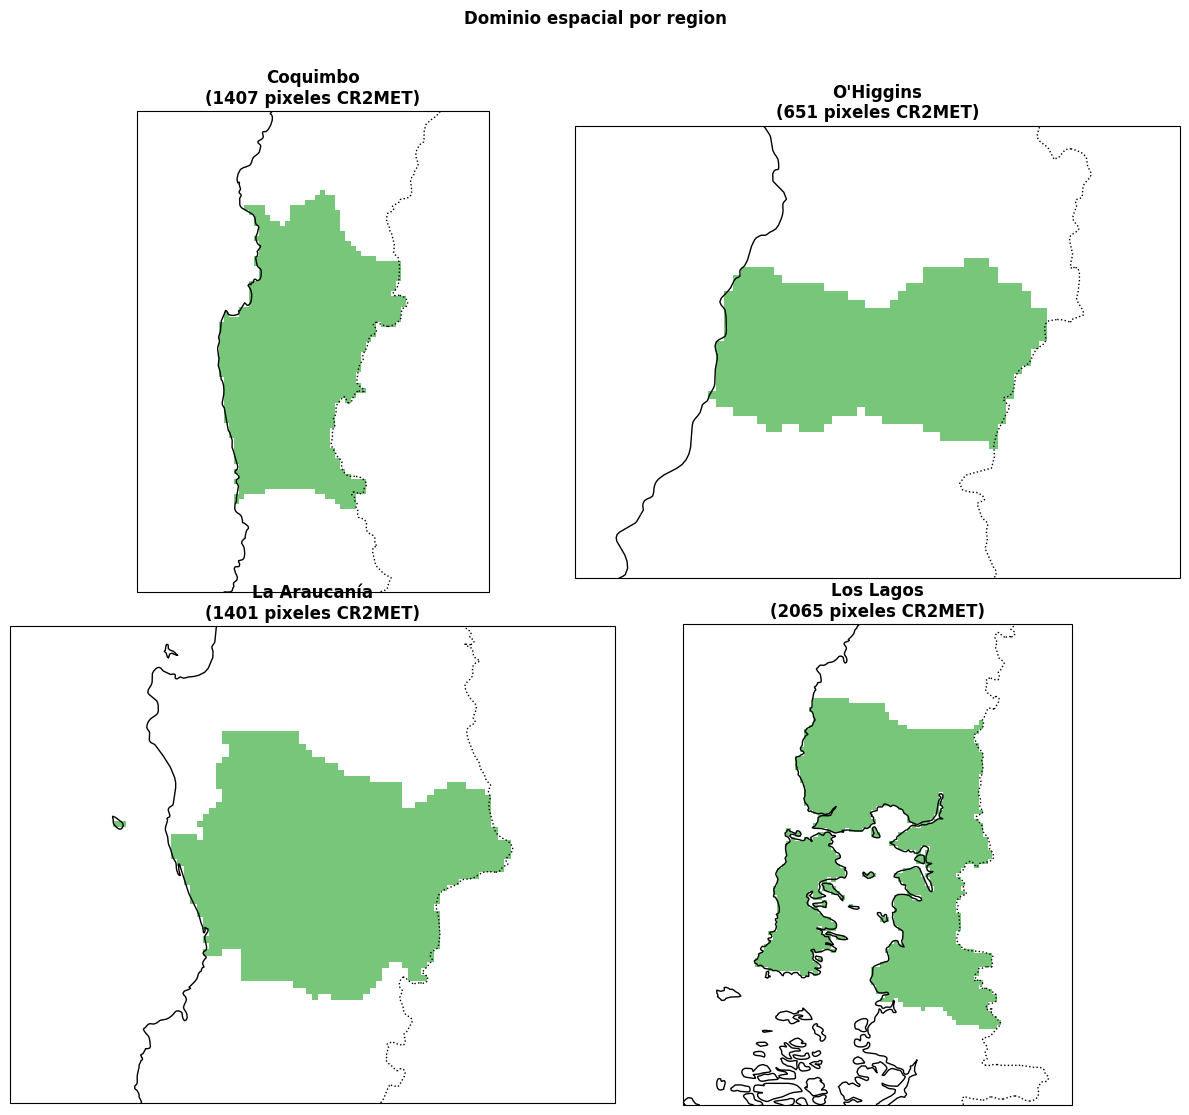

In [2]:
# =====================================================================
# EXTRACCION DE DRY SPELLS EN LAS 4 REGIONES
# =====================================================================
print('2/4: Extrayendo dry spells por region...')

REGION_DATA = {}
for label, spec in REGION_SPECS.items():
    record = get_region_record(spec['query'], CHILE_REGIONS)
    data = load_region_spell_data(ds, record)
    REGION_DATA[label] = data
    print(
        f"  {label:16s} | {data['name']:22s} | "
        f"pixeles: {data['pixels']:4d} | spells: {len(data['spell_df']):,}"
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 11), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.ravel()

for ax, (label, spec) in zip(axes, REGION_SPECS.items()):
    data = REGION_DATA[label]
    minx, miny, maxx, maxy = data['bounds']
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([minx - 0.8, maxx + 0.8, miny - 0.8, maxy + 0.8])

    plot_da = data['mask_da'].astype(float).where(data['mask_da'])
    plot_da.plot.pcolormesh(
        ax=ax, x='lon', y='lat', transform=ccrs.PlateCarree(),
        cmap='YlGn', add_colorbar=False,
    )
    ax.set_title(f"{label}\n({data['pixels']} pixeles CR2MET)", fontweight='bold')

fig.suptitle('Dominio espacial por region', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [3]:
# =====================================================================
# RISK RATIO A 20 DIAS + BOOTSTRAP (4 REGIONES)
# =====================================================================
print(f'3/4: Risk ratio para dry spells >= {EVENT_THRESHOLD} dias...')

years_1 = range(PERIOD_1[0], PERIOD_1[1] + 1)
years_2 = range(PERIOD_2[0], PERIOD_2[1] + 1)

summary_rows = []
rr_rows = []

for label in REGION_SPECS:
    spell_df = REGION_DATA[label]['spell_df']

    _, prob_1, hits_1, total_1 = event_probability(spell_df, PERIOD_1[0], PERIOD_1[1], EVENT_THRESHOLD)
    _, prob_2, hits_2, total_2 = event_probability(spell_df, PERIOD_2[0], PERIOD_2[1], EVENT_THRESHOLD)
    rr_obs = risk_ratio(prob_2, prob_1)

    rr_boot = bootstrap_rr_by_year(spell_df, years_1, years_2, EVENT_THRESHOLD)
    if rr_boot.size > 0:
        ci_low, ci_med, ci_high = np.percentile(rr_boot, [2.5, 50, 97.5])
    else:
        ci_low = ci_med = ci_high = np.nan

    summary_rows.extend([
        {
            'Region': label,
            'Periodo': f'{PERIOD_1[0]}-{PERIOD_1[1]}',
            'Dry spells totales': total_1,
            f'Spells >= {EVENT_THRESHOLD} d': hits_1,
            'Probabilidad (%)': prob_1 * 100 if np.isfinite(prob_1) else np.nan,
        },
        {
            'Region': label,
            'Periodo': f'{PERIOD_2[0]}-{PERIOD_2[1]}',
            'Dry spells totales': total_2,
            f'Spells >= {EVENT_THRESHOLD} d': hits_2,
            'Probabilidad (%)': prob_2 * 100 if np.isfinite(prob_2) else np.nan,
        },
    ])

    rr_rows.append({
        'Region': label,
        'Pixeles': REGION_DATA[label]['pixels'],
        'RR observado': rr_obs,
        'RR bootstrap mediano': ci_med,
        'IC95 inferior': ci_low,
        'IC95 superior': ci_high,
        'Cruza RR=1': (ci_low <= 1 <= ci_high) if np.all(np.isfinite([ci_low, ci_high])) else np.nan,
    })

summary_table = pd.DataFrame(summary_rows)
rr_table = pd.DataFrame(rr_rows)

display(summary_table.round(3))
display(rr_table.round(3))


3/4: Risk ratio para dry spells >= 20 dias...


,Region,Periodo,Dry spells totales,Spells >= 20 d,Probabilidad (%)
0,Coquimbo,1979-2000,531229,134925,25.399
1,Coquimbo,2001-2021,432899,123633,28.559
2,O'Higgins,1979-2000,414261,48471,11.701
3,O'Higgins,2001-2021,379532,48146,12.686
4,La Araucanía,1979-2000,1417527,34021,2.400
5,La Araucanía,2001-2021,1391808,31792,2.284
6,Los Lagos,1979-2000,2160875,7177,0.332
7,Los Lagos,2001-2021,2067452,9275,0.449


,Region,Pixeles,RR observado,RR bootstrap mediano,IC95 inferior,IC95 superior,Cruza RR=1
0,Coquimbo,1407,1.124,1.124,0.963,1.324,True
1,O'Higgins,651,1.084,1.085,0.904,1.271,True
2,La Araucanía,1401,0.952,0.942,0.710,1.280,True
3,Los Lagos,2065,1.351,1.356,0.482,3.342,True


4/4: Risk ratio como funcion del umbral de duracion (4 regiones)...


,Umbral (dias),P1 (%),P2 (%),RR,Eventos P1,Eventos P2,Region
0,20,25.399,28.559,1.124,134925,123633,Coquimbo
1,20,11.701,12.686,1.084,48471,48146,O'Higgins
2,20,2.400,2.284,0.952,34021,31792,La Araucanía
3,20,0.332,0.449,1.351,7177,9275,Los Lagos


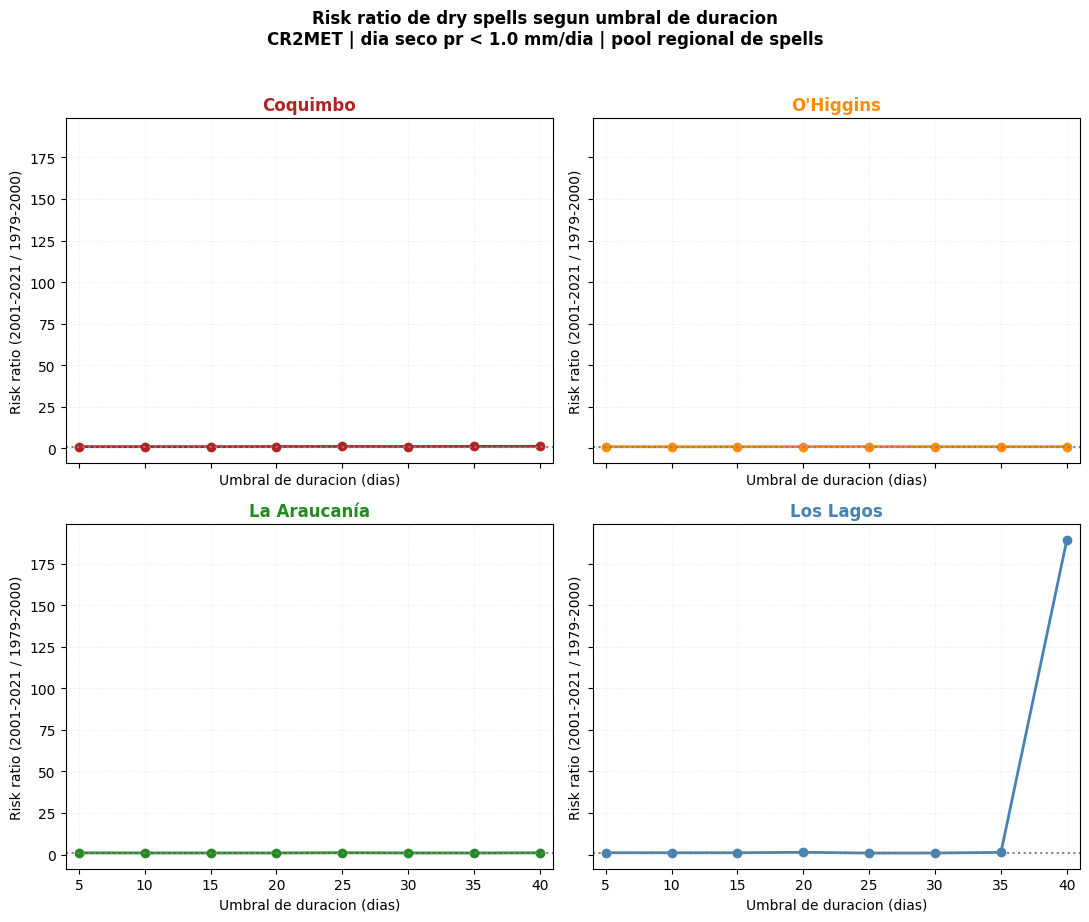

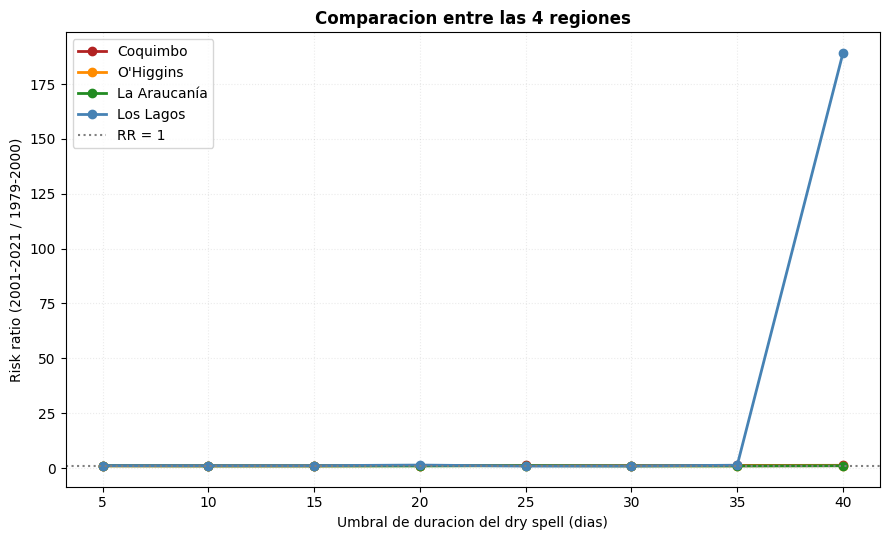

Lectura:
  - RR > 1: el evento es mas probable en 2001-2021 que en 1979-2000.
  - RR < 1: menos probable en el periodo reciente.
  - RR = 1 o IC95 que cruza 1: sin evidencia clara de cambio.
  - Umbrales altos: si P1 -> 0, el RR puede volverse inestable (NaN).


In [4]:
# =====================================================================
# FIGURA ESTILO FIG. 5: RR VS UMBRAL DE DURACION (PANELES 2x2)
# =====================================================================
print('4/4: Risk ratio como funcion del umbral de duracion (4 regiones)...')

threshold_by_region = {}

for label in REGION_SPECS:
    spell_df = REGION_DATA[label]['spell_df']
    rows = []
    for threshold in THRESHOLD_SWEEP:
        _, p1, h1, n1 = event_probability(spell_df, PERIOD_1[0], PERIOD_1[1], threshold)
        _, p2, h2, n2 = event_probability(spell_df, PERIOD_2[0], PERIOD_2[1], threshold)
        rows.append({
            'Umbral (dias)': threshold,
            'P1 (%)': p1 * 100 if np.isfinite(p1) else np.nan,
            'P2 (%)': p2 * 100 if np.isfinite(p2) else np.nan,
            'RR': risk_ratio(p2, p1),
            'Eventos P1': h1,
            'Eventos P2': h2,
        })
    threshold_by_region[label] = pd.DataFrame(rows)

# Tabla consolidada (umbral 20 dias)
table_20 = pd.concat(
    [threshold_by_region[label].loc[threshold_by_region[label]['Umbral (dias)'] == EVENT_THRESHOLD]
     .assign(Region=label)
     for label in REGION_SPECS],
    ignore_index=True,
)
display(table_20.round(3))

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (label, spec) in zip(axes, REGION_SPECS.items()):
    tdf = threshold_by_region[label]
    color = spec['color']

    valid = tdf['RR'].notna()
    ax.plot(
        tdf.loc[valid, 'Umbral (dias)'],
        tdf.loc[valid, 'RR'],
        color=color,
        marker='o',
        linewidth=2,
        markersize=6,
    )
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(label, fontweight='bold', color=color)
    ax.set_xlabel('Umbral de duracion (dias)')
    ax.set_ylabel('Risk ratio (2001-2021 / 1979-2000)')
    ax.set_xlim(THRESHOLD_SWEEP[0] - 1, THRESHOLD_SWEEP[-1] + 1)

fig.suptitle(
    'Risk ratio de dry spells segun umbral de duracion\n'
    f'CR2MET | dia seco pr < {DRY_THRESHOLD} mm/dia | pool regional de spells',
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.show()

# Panel combinado (4 curvas en un solo eje)
fig, ax = plt.subplots(figsize=(9, 5.5))
for label, spec in REGION_SPECS.items():
    tdf = threshold_by_region[label]
    valid = tdf['RR'].notna()
    ax.plot(
        tdf.loc[valid, 'Umbral (dias)'],
        tdf.loc[valid, 'RR'],
        color=spec['color'],
        marker='o',
        linewidth=2,
        label=label,
    )

ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.5, label='RR = 1')
ax.set_xlabel('Umbral de duracion del dry spell (dias)')
ax.set_ylabel('Risk ratio (2001-2021 / 1979-2000)')
ax.set_title('Comparacion entre las 4 regiones', fontweight='bold')
ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

print('Lectura:')
print('  - RR > 1: el evento es mas probable en 2001-2021 que en 1979-2000.')
print('  - RR < 1: menos probable en el periodo reciente.')
print('  - RR = 1 o IC95 que cruza 1: sin evidencia clara de cambio.')
print('  - Umbrales altos: si P1 -> 0, el RR puede volverse inestable (NaN).')
